# Support Vector Regression (SVR) - Beginner Friendly Walkthrough

## 1. Import Required Libraries

In [3]:
# Basic libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

## 2. Create an Intuitive Dataset

In [6]:
# Create a synthetic regression dataset
X, y = make_regression(n_samples=200, 
                       n_features=1, 
                       noise=15,    # Add some noise
                       random_state=42)

# Convert to pandas DataFrame
data = pd.DataFrame(X, columns=['Feature'])
data['Target'] = y

data.head()

,Feature,Target
0,1.852278,143.450823
1,0.473592,54.639848
2,-1.230864,-84.442236
3,0.625667,59.326531
4,-0.072010,-8.244156


## 3. Visualize the Dataset

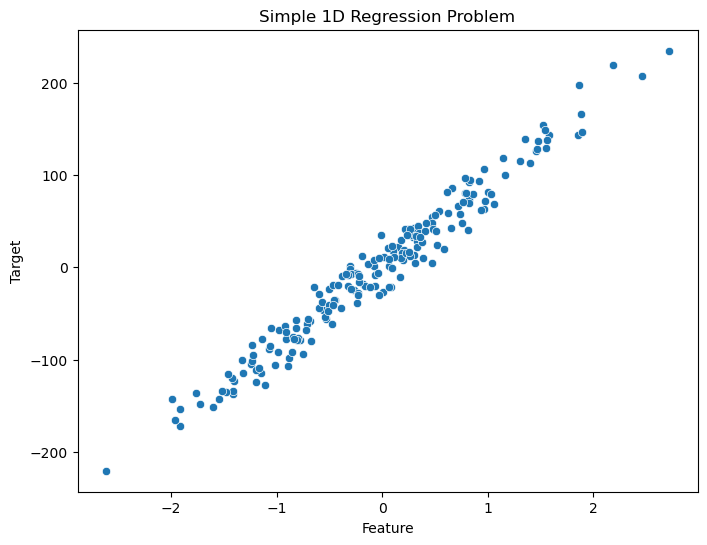

In [9]:
# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x='Feature', y='Target')
plt.title('Simple 1D Regression Problem')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.show()

## 4. Split the Data

In [12]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 140
Testing samples: 60


## 5. Build the SVR Model

In [15]:
# Create the SVR model
model = SVR(kernel='linear', C=100, epsilon=10)

# Train the model
model.fit(X_train, y_train)

SVR(C=100, epsilon=10, kernel='linear')

C=100: Allow less slack (harder on errors)

epsilon=10: Allow a small "tube" of ±10 error without penalty

## 6. Make Predictions

In [19]:
# Predict on test data
y_pred = model.predict(X_test)

## 7. Evaluate the Model

### Mean Squared Error

In [23]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 260.77


### R2 Score

In [27]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.2f}")

R² Score: 0.97


## 8. Visualize the SVR Line and ε-Tube

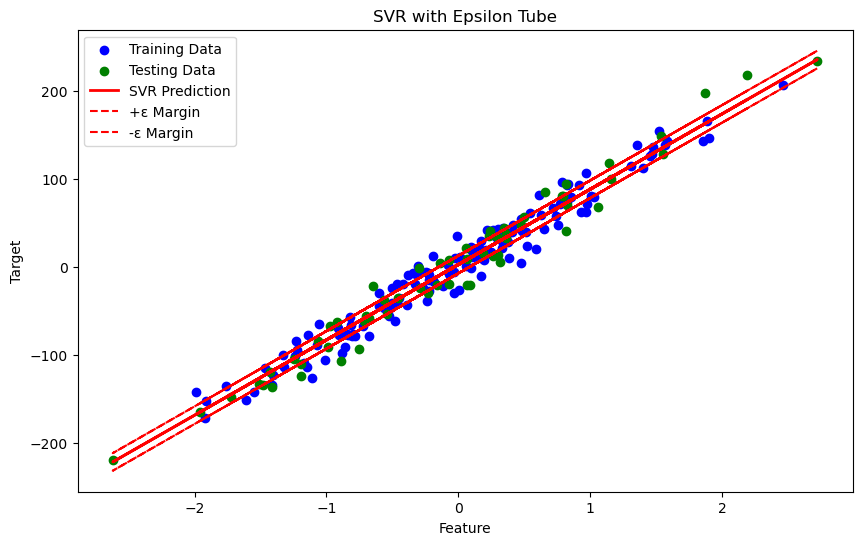

In [30]:
# Plot predictions
plt.figure(figsize=(10,6))

# Plot training points
plt.scatter(X_train, y_train, color='blue', label='Training Data')
# Plot testing points
plt.scatter(X_test, y_test, color='green', label='Testing Data')

# Plot regression line
plt.plot(X_test, y_pred, color='red', linewidth=2, label='SVR Prediction')

# Plot epsilon-tube boundaries
plt.plot(X_test, y_pred + 10, 'r--', label='+ε Margin')
plt.plot(X_test, y_pred - 10, 'r--', label='-ε Margin')

plt.title('SVR with Epsilon Tube')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.legend()
plt.show()

 9. Summary of What We Learned
SVR tries to fit a line with a tube of width 2ε (epsilon).

Points inside the tube are not penalized (small acceptable error).

Points outside the tube are penalized (big error).

C parameter controls how much errors are tolerated: ➔ Large C = tighter fit, fewer tolerated errors
➔ Small C = looser fit, more tolerated errors

Linear kernel works when the data has a roughly linear relationship.


---

✅ This builds your **intuition** about:  
- How **SVR** fits a line  
- What **epsilon** really means (a tube, not a strict line!)  
- How to control **flexibility** with **C** and **ε**  

---
